# Viscoelastic wave propagator with Maxwell - GSLS formulation #

This tutorial was prepared by Paula Neves de Araujo (paulan@ime.usp.br).

This tutorial is an introduction to the viscoelastic wave propagator of Spyro using the Maxwell - GSLS formulation.

First, the notebook environment is configured and the required modules are imported. If you are running this notebook in Google colab, please copy the following code into a code block before running the notebook:

```python
# For use in colab only:
try:
    import firedrake
except ImportError:
    !wget "https://fem-on-colab.github.io/releases/firedrake-install-real.sh" -O "/tmp/firedrake-install.sh" && bash "/tmp/firedrake-install.sh"
    import firedrake

!pip install git+https://github.com/NDF-Poli-USP/spyro.git

In [2]:
%matplotlib inline
import spyro
import numpy as np

from firedrake import *

firedrake:WARNING OMP_NUM_THREADS is not set or is set to a value greater than 1, we suggest setting OMP_NUM_THREADS=1 to improve performance


We define some basic parameters for the simulation:

In [3]:
source_location = (-500.0, 500.0)

receiver_location = spyro.create_transect(
    (-450.0, -450.0),
    (-450.0,  450.0),
    300
)

dx_target = 10 
dt = 0.0005
final_time = 0.4
frequency = 10.0
omega0 = 2.0 * np.pi * frequency

domain_size = 1000.0 

rho = 2000.0
vp = 2500.0
vs = vp / 1.732
mu = rho * vs**2
lmbda = rho * (vp**2 - 2 * vs**2)

amplitude = np.array([0.0, 5e7])

fmin = 1e-1
fmax = 3 * frequency
L = 5
nf = 100

In [4]:
def compute_y_coefficients(fmin, fmax, L, nfreqs=100):
    freqs_relax = np.logspace(np.log10(fmin), np.log10(fmax), L)
    omega_relax = 2 * np.pi * freqs_relax
    f_sample = np.linspace(fmin, fmax, nfreqs)
    omega_sample = 2 * np.pi * f_sample
    A = np.zeros((nfreqs, L))
    for i, w in enumerate(omega_sample):
        for j, wl in enumerate(omega_relax):
            A[i, j] = (wl * w) / (w**2 + wl**2)
    b = np.ones(nfreqs)
    y, _, _, _ = np.linalg.lstsq(A, b, rcond=None)
    return y, omega_relax

y, omega_relax = compute_y_coefficients(fmin, fmax, L, nfreqs=nf)

In the following example, our goal is to perform the viscoelastic wave propagation in layered media and, for this aim, we define functions for velocity and viscoelastic parameters based on coordinates:

In [5]:
qp_data = lambda mesh: conditional(
        SpatialCoordinate(mesh)[1] < domain_size/2, 
        1/10.0, 
        1/20.0
    )
qs_data = lambda mesh: conditional(
        SpatialCoordinate(mesh)[1] < domain_size/2, 
        1/10.0, 
        1/20.0
    )

vp_data = lambda mesh: conditional(
        SpatialCoordinate(mesh)[1] < domain_size/2, 
        vp, 
        2*vp/3
    )
vs_data = lambda mesh: conditional(
        SpatialCoordinate(mesh)[1] < domain_size/2, 
        vs, 
        2*vs/3
    )

We define a new dictionary based on these parameters:

In [6]:
layered_base_dictionary = {
    "options": {
        "cell_type": "T",
        "variant": "lumped",
        "degree": 2,
        "dimension": 2,
    },
    "wave_type": 'isotropic',
    "parallelism": {"type": "automatic"},
    "mesh": {
        "Lz": domain_size,
        "Lx": domain_size,
        "mesh_file": None,
        "mesh_type": "firedrake_mesh",
    },
    "acquisition": {
        "source_type": "ricker",
        "source_locations": [source_location],
        "frequency": frequency,
        "delay": 0.2,
        "delay_type": "time",
        "receiver_locations": receiver_location,
        "amplitude": amplitude,
    },
    "time_axis": {
        "initial_time": 0.0,
        "final_time": final_time,
        "dt": dt,
        "output_frequency": 100,
        "gradient_sampling_frequency": 1,
    },
    "visualization": {
        "forward_output": True,
        "forward_output_filename": "results/forward_output.pvd",
        "fwi_velocity_model_output": False,
        "velocity_model_filename": None,
        "gradient_output": False,
        "gradient_filename": "results/Gradient.pvd",
        "adjoint_output": False,
        "adjoint_filename": None,
        "debug_output": False,
    },
    "synthetic_data": {
        "type": "conditional",
        "density": rho,
        "p_wave_velocity": vp_data,
        "s_wave_velocity": vs_data,
        "real_velocity_file": None,
    },
}

In [7]:
layered_viscoelastic_isotropic_dictionary = layered_base_dictionary.copy()

In [8]:
layered_viscoelastic_isotropic_dictionary["viscoelasticity"] = {
    "viscoelastic": True,
    "visco_type": "maxwell_gsls_Q",
    "Q_type": 'cond',          # agora usamos funções espaciais
    "branches": L,
    "omega_gsls": omega_relax,
    "y_gsls": y,
    "Qp_inv": qp_data, # função com 1/Qp
    "Qs_inv": qs_data, # função com 1/Qs
    "lmbda_s": lmbda,
    "mu_s": mu,
}

In [9]:
layered_viscoelastic_isotropic_wave = spyro.IsotropicWave(layered_viscoelastic_isotropic_dictionary)

layered_viscoelastic_isotropic_wave.set_mesh(mesh_parameters={"dx": dx_target, "periodic": True})

layered_viscoelastic_isotropic_wave.forward_solve()

Parallelism type: automatic


/home/paulanevesdearaujo/spyro-dev/attenuation_isotropic/spyro/io/model_parameters.py:579: UserWarning: No velocity model set initially. If using user defined conditional or expression, please input it in the Wave object.
  warnings.warn(
/home/paulanevesdearaujo/spyro-dev/attenuation_isotropic/spyro/solvers/wave.py:84: UserWarning: No mesh file, Firedrake mesh will be automatically generated.
  warnings.warn(


Viscoelastic Maxwell/GSLS (Q-based) - Voigt notation (generalized C::Gamma)
Saving Displacement in: results/forward_outputsn0.pvd


/home/paulanevesdearaujo/venv-firedrake/lib/python3.12/site-packages/ufl/utils/sorting.py:88: UserWarning: Applying str() to a metadata value of type QuadratureRule, don't know if this is safe.
  warnings.warn(
/home/paulanevesdearaujo/venv-firedrake/lib/python3.12/site-packages/ufl/utils/sorting.py:88: UserWarning: Applying str() to a metadata value of type QuadratureRule, don't know if this is safe.
  warnings.warn(
/home/paulanevesdearaujo/venv-firedrake/lib/python3.12/site-packages/ufl/utils/sorting.py:88: UserWarning: Applying str() to a metadata value of type QuadratureRule, don't know if this is safe.
  warnings.warn(


Simulation time is:        0.0 seconds
Simulation time is:       0.05 seconds
Simulation time is:        0.1 seconds
Simulation time is:       0.15 seconds
Simulation time is:        0.2 seconds
Simulation time is:       0.25 seconds
Simulation time is:        0.3 seconds
Simulation time is:       0.35 seconds
Simulation time is:        0.4 seconds


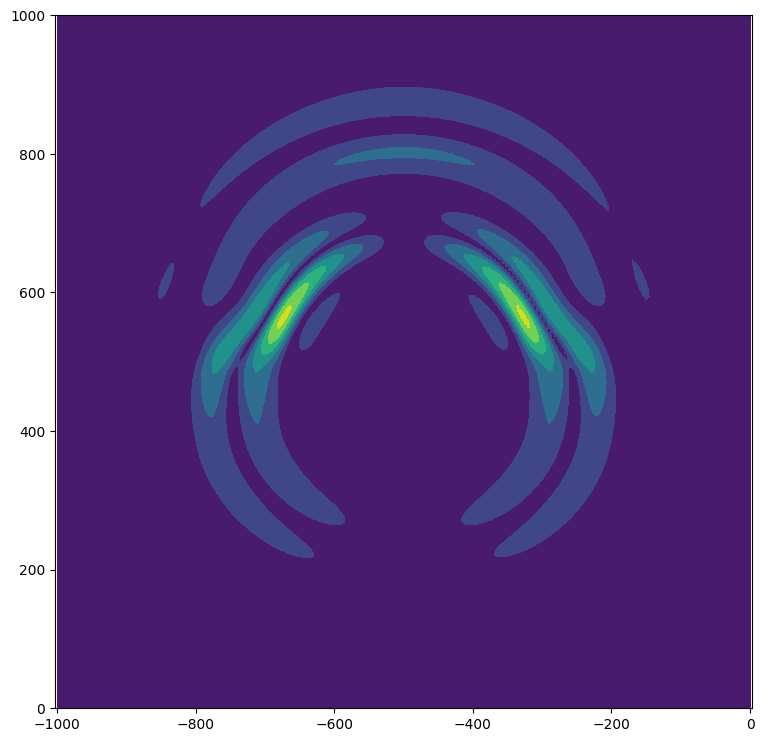

In [10]:
spyro.plots.plot_function(layered_viscoelastic_isotropic_wave.u_n)

We run the elastic case for the comparison with the viscoelastic case:

In [11]:
layered_elastic_isotropic_dictionary = layered_base_dictionary.copy()

layered_elastic_isotropic_wave = spyro.IsotropicWave(layered_elastic_isotropic_dictionary)

layered_elastic_isotropic_wave.set_mesh(mesh_parameters={"dx": dx_target, "periodic": True})

layered_elastic_isotropic_wave.forward_solve()

Parallelism type: automatic


/home/paulanevesdearaujo/spyro-dev/attenuation_isotropic/spyro/io/model_parameters.py:579: UserWarning: No velocity model set initially. If using user defined conditional or expression, please input it in the Wave object.
  warnings.warn(
/home/paulanevesdearaujo/spyro-dev/attenuation_isotropic/spyro/solvers/wave.py:84: UserWarning: No mesh file, Firedrake mesh will be automatically generated.
  warnings.warn(


Elastic wave propagation
Saving Displacement in: results/forward_outputsn0.pvd


/home/paulanevesdearaujo/venv-firedrake/lib/python3.12/site-packages/ufl/utils/sorting.py:88: UserWarning: Applying str() to a metadata value of type QuadratureRule, don't know if this is safe.
  warnings.warn(
/home/paulanevesdearaujo/venv-firedrake/lib/python3.12/site-packages/ufl/utils/sorting.py:88: UserWarning: Applying str() to a metadata value of type QuadratureRule, don't know if this is safe.
  warnings.warn(
/home/paulanevesdearaujo/venv-firedrake/lib/python3.12/site-packages/ufl/utils/sorting.py:88: UserWarning: Applying str() to a metadata value of type QuadratureRule, don't know if this is safe.
  warnings.warn(


Simulation time is:        0.0 seconds
Simulation time is:       0.05 seconds
Simulation time is:        0.1 seconds
Simulation time is:       0.15 seconds
Simulation time is:        0.2 seconds
Simulation time is:       0.25 seconds
Simulation time is:        0.3 seconds
Simulation time is:       0.35 seconds
Simulation time is:        0.4 seconds


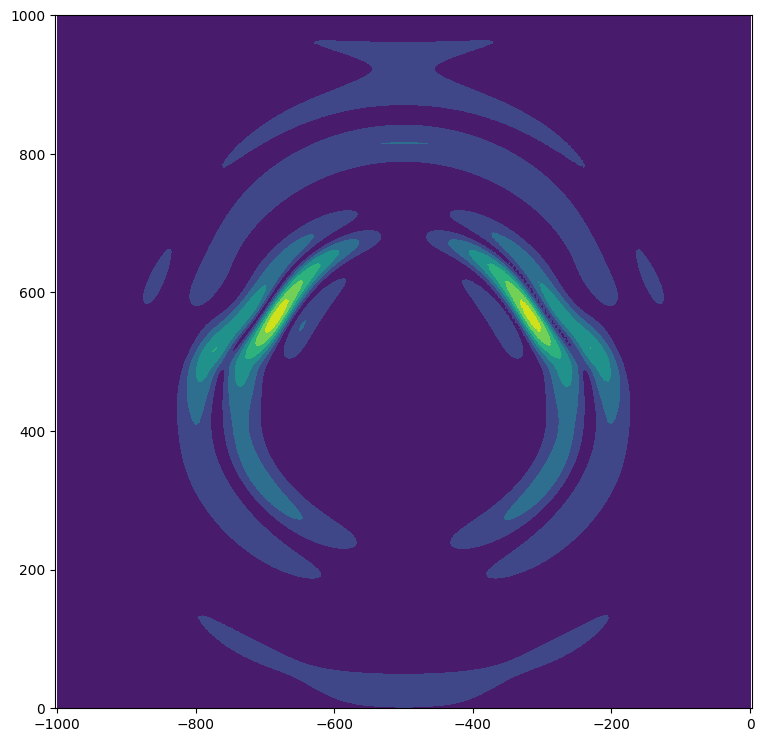

In [12]:
spyro.plots.plot_function(layered_elastic_isotropic_wave.u_n)

In [13]:
layered_viscoelastic_anisotropic_dictionary = layered_viscoelastic_isotropic_dictionary.copy()

In [24]:
layered_viscoelastic_anisotropic_dictionary["wave_type"] = 'anisotropic_VTI'
layered_viscoelastic_anisotropic_dictionary["anisotropy"] = {
    'epsilon':0.3, 
    'gamma': 0.1,
    'delta': 0.15,
    'anisotropy': 'exact'
}

layered_viscoelastic_anisotropic_dictionary["viscoelasticity"]["Qepsilon_inv"] = qp_data # função com 1/Qp
layered_viscoelastic_anisotropic_dictionary["viscoelasticity"]["Qdelta_inv"] = qp_data # função com 1/Qp
layered_viscoelastic_anisotropic_dictionary["viscoelasticity"]["Qgamma_inv"] = qp_data # função com 1/Qp

In [25]:
layered_viscoelastic_anisotropic_wave = spyro.IsotropicWave(layered_viscoelastic_anisotropic_dictionary)

layered_viscoelastic_anisotropic_wave.set_mesh(mesh_parameters={"dx": dx_target, "periodic": True})

layered_viscoelastic_anisotropic_wave.forward_solve()

Parallelism type: automatic


/home/paulanevesdearaujo/spyro-dev/attenuation_isotropic/spyro/io/model_parameters.py:579: UserWarning: No velocity model set initially. If using user defined conditional or expression, please input it in the Wave object.
  warnings.warn(
/home/paulanevesdearaujo/spyro-dev/attenuation_isotropic/spyro/solvers/wave.py:84: UserWarning: No mesh file, Firedrake mesh will be automatically generated.
  warnings.warn(


Viscoelastic Maxwell/GSLS (Q-based) - Voigt notation (generalized C::Gamma)
Saving Displacement in: results/forward_outputsn0.pvd


/home/paulanevesdearaujo/venv-firedrake/lib/python3.12/site-packages/ufl/utils/sorting.py:88: UserWarning: Applying str() to a metadata value of type QuadratureRule, don't know if this is safe.
  warnings.warn(
/home/paulanevesdearaujo/venv-firedrake/lib/python3.12/site-packages/ufl/utils/sorting.py:88: UserWarning: Applying str() to a metadata value of type QuadratureRule, don't know if this is safe.
  warnings.warn(
/home/paulanevesdearaujo/venv-firedrake/lib/python3.12/site-packages/ufl/utils/sorting.py:88: UserWarning: Applying str() to a metadata value of type QuadratureRule, don't know if this is safe.
  warnings.warn(


Simulation time is:        0.0 seconds
Simulation time is:       0.05 seconds
Simulation time is:        0.1 seconds
Simulation time is:       0.15 seconds
Simulation time is:        0.2 seconds
Simulation time is:       0.25 seconds
Simulation time is:        0.3 seconds
Simulation time is:       0.35 seconds
Simulation time is:        0.4 seconds


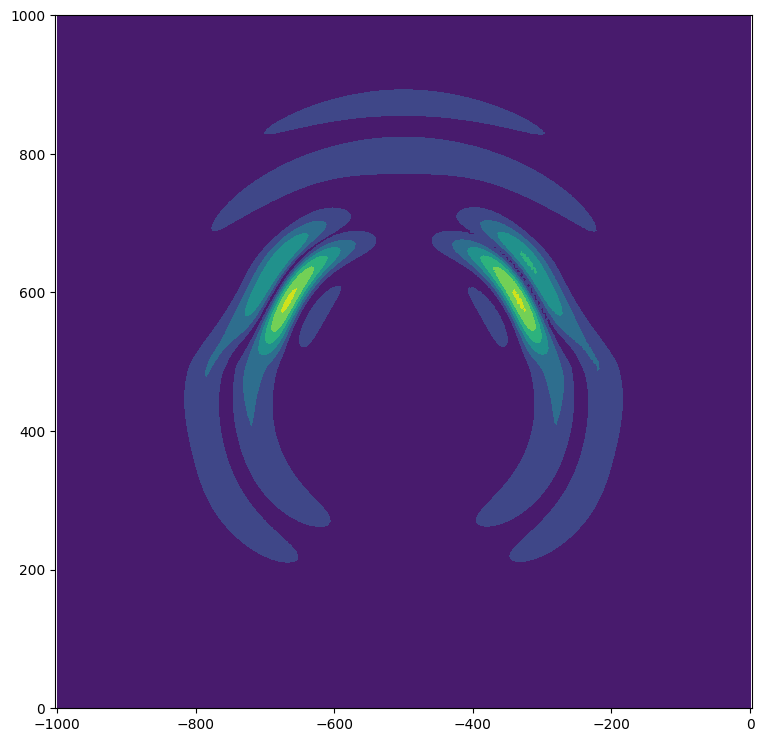

In [27]:
spyro.plots.plot_function(layered_viscoelastic_anisotropic_wave.u_n)